In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
path = "/content/drive/My Drive/Colab Notebooks/datata/"

In [15]:
classes = os.listdir(path)

print(classes)

['diam', 'jalan', 'diamjatuh', 'jalanjatuh']


In [16]:
for cls in classes:

    folder = os.path.join(path, cls)

    if os.path.isdir(folder):

        files = os.listdir(folder)

        print(cls, ":", len(files), "files")

diam : 11 files
jalan : 17 files
diamjatuh : 68 files
jalanjatuh : 71 files


In [17]:
for cls in classes:

    folder = os.path.join(path, cls)

    if os.path.isdir(folder):

        files = os.listdir(folder)

        print("\nCLASS:", cls)

        for f in files[:5]:

            print(f)


CLASS: diam
diam1.csv
diam2.csv
diam3.csv
diam4.csv
diam_rebahsantai_20260524_020550.csv

CLASS: jalan
jalan1.csv
jalan2.csv
jalan3.csv
jalan4.csv
jalan5.csv

CLASS: diamjatuh
diamjatuh_01.csv
diamjatuh_011.csv
diamjatuh_012.csv
diamjatuh_02.csv
diamjatuh_021.csv

CLASS: jalanjatuh
jalanjatuh_jnormal_depan_langsung.csv
jalanjatuh_jnormal_depan_langsung (2).csv
jalanjatuh_jnormal_depan_tangan.csv
jalanjatuh_jnormal_belakang_tangan.csv
jalanjatuh_jnormal_belakang_langsung.csv


In [18]:
class_name = "diamjatuh"

folder = os.path.join(path, class_name)

file_name = os.listdir(folder)[0]

file_path = os.path.join(folder, file_name)

print(file_path)

/content/drive/My Drive/Colab Notebooks/datata/diamjatuh/diamjatuh_01.csv


In [19]:
df = pd.read_csv(file_path)

df.head()

,seq,timestamp_ms,ax,ay,az,gx,gy,gz
0,3300,18210,0.1104,0.7478,-0.6619,-1.9847,0.8702,-0.4351
1,3301,18215,0.1155,0.7537,-0.6685,-1.6412,0.7099,-0.3206
2,3302,18220,0.1160,0.7500,-0.6619,-2.0611,0.0000,-0.4275
3,3303,18225,0.1160,0.7510,-0.6604,-1.9695,-0.2748,-0.4809
4,3304,18230,0.1199,0.7466,-0.6672,-2.2214,-0.0305,-0.8473


In [20]:
print("Jumlah sample :", len(df))

Jumlah sample : 3815


In [21]:
df["acc_mag"] = np.sqrt(
    df["ax"]**2 +
    df["ay"]**2 +
    df["az"]**2
)

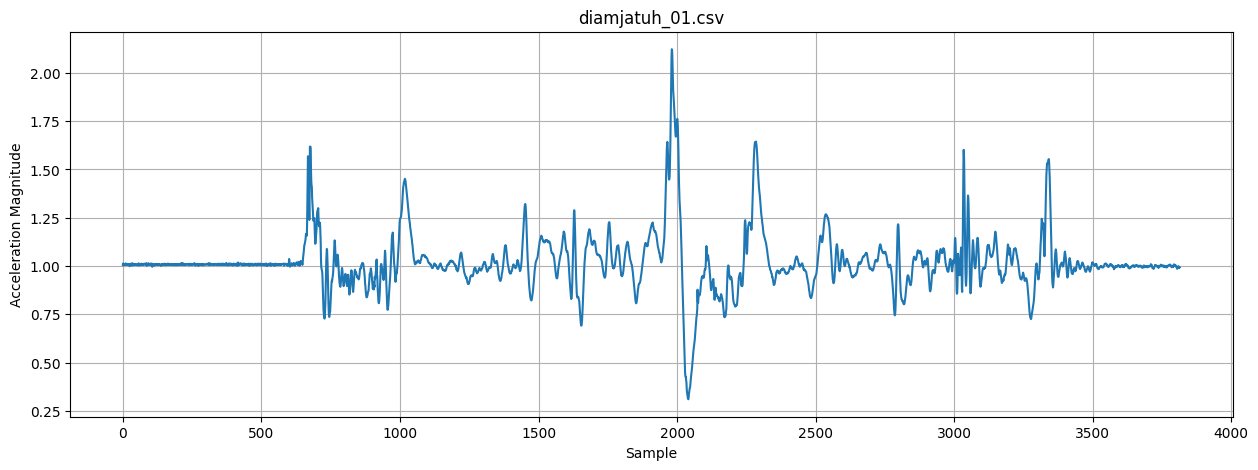

In [22]:
plt.figure(figsize=(15,5))

plt.plot(df["acc_mag"])

plt.title(file_name)

plt.xlabel("Sample")
plt.ylabel("Acceleration Magnitude")

plt.grid()

plt.show()

In [23]:
for cls in classes:

    folder = os.path.join(path, cls)

    if os.path.isdir(folder):

        files = os.listdir(folder)

        for f in files:

            fp = os.path.join(folder, f)

            try:

                df = pd.read_csv(fp)

                if len(df) < 1000:

                    print("TERLALU PENDEK :", cls, f, len(df))

            except:

                print("ERROR :", fp)

TERLALU PENDEK : jalan berdiri_lalu_jalan03_20260524_022409.csv 792
TERLALU PENDEK : diamjatuh diamjatuh_05.csv 826
TERLALU PENDEK : diamjatuh diamjatuh_tidurmenjangkau_kanan_langsung1.csv 717
TERLALU PENDEK : jalanjatuh jalanjatuh_b5cepat_tersandung_tangan.csv 949


In [24]:
for cls in classes:

    folder = os.path.join(path, cls)

    if os.path.isdir(folder):

        files = os.listdir(folder)

        for f in files:

            fp = os.path.join(folder, f)

            try:

                df = pd.read_csv(fp)

                if len(df) > 4000:

                    print("TERLALU PANJANG :", cls, f, len(df))

            except:

                print("ERROR :", fp)

TERLALU PANJANG : diam diam1.csv 17040
TERLALU PANJANG : diam diam2.csv 16224
TERLALU PANJANG : diam diam3.csv 16431
TERLALU PANJANG : diam diam4.csv 16117
TERLALU PANJANG : diam diam_rebahsantai_20260524_020550.csv 6669
TERLALU PANJANG : diam melihat_hp_20260524_020724.csv 6455
TERLALU PANJANG : diam membungkuk_20260524_020823.csv 6316
TERLALU PANJANG : diam duduk_berubah_posisi_20260524_020925.csv 6888
TERLALU PANJANG : diam gerak_tangan_kecil_20260524_021025.csv 6464
TERLALU PANJANG : diam geser_badan_20260524_021124.csv 6636
TERLALU PANJANG : diam diam_tangandada_20260526_021303.csv 8072
TERLALU PANJANG : jalan jalan1.csv 17378
TERLALU PANJANG : jalan jalan2.csv 15775
TERLALU PANJANG : jalan jalan3.csv 14497
TERLALU PANJANG : jalan jalan4.csv 12545
TERLALU PANJANG : jalan jalan5.csv 12857
TERLALU PANJANG : jalan jalan_berhenti_mendadak_20260524_021248.csv 6570
TERLALU PANJANG : jalan jalan_belok_cepat_20260524_021339.csv 6435
TERLALU PANJANG : jalan jalan_langkah_tidak_stabil_20260

In [25]:
all_info = []

for cls in classes:

    folder = os.path.join(path, cls)

    if os.path.isdir(folder):

        files = os.listdir(folder)

        for f in files:

            fp = os.path.join(folder, f)

            try:

                df = pd.read_csv(fp)

                total_sample = len(df)

                duration = total_sample / 200.0

                all_info.append([
                    cls,
                    f,
                    total_sample,
                    duration
                ])

            except Exception as e:

                print("ERROR :", fp)
                print(e)

In [26]:
info_df = pd.DataFrame(
    all_info,
    columns=[
        "class",
        "file",
        "samples",
        "duration_sec"
    ]
)

info_df.head()

,class,file,samples,duration_sec
0,diam,diam1.csv,17040,85.200
1,diam,diam2.csv,16224,81.120
2,diam,diam3.csv,16431,82.155
3,diam,diam4.csv,16117,80.585
4,diam,diam_rebahsantai_20260524_020550.csv,6669,33.345


In [27]:
info_df

,class,file,samples,duration_sec
0,diam,diam1.csv,17040,85.200
1,diam,diam2.csv,16224,81.120
2,diam,diam3.csv,16431,82.155
3,diam,diam4.csv,16117,80.585
4,diam,diam_rebahsantai_20260524_020550.csv,6669,33.345
...,...,...,...,...
162,jalanjatuh,jalanpelan_tersandung_langsung.csv,2174,10.870
163,jalanjatuh,jalanpelan_tersandung_langsung1.csv,2277,11.385
164,jalanjatuh,jalancepat_tersandung_langsung.csv,2251,11.255
165,jalanjatuh,jalancepat_tersandung_tangan.csv,2267,11.335


In [28]:
info_df.describe()

,samples,duration_sec
count,167.000000,167.000000
mean,3566.143713,17.830719
std,3105.799426,15.528997
min,717.000000,3.585000
25%,2360.000000,11.800000
50%,2534.000000,12.670000
75%,2779.000000,13.895000
max,17378.000000,86.890000


In [29]:
info_df.sort_values(
    by="samples"
)

,class,file,samples,duration_sec
90,diamjatuh,diamjatuh_tidurmenjangkau_kanan_langsung1.csv,717,3.585
26,jalan,berdiri_lalu_jalan03_20260524_022409.csv,792,3.960
35,diamjatuh,diamjatuh_05.csv,826,4.130
141,jalanjatuh,jalanjatuh_b5cepat_tersandung_tangan.csv,949,4.745
166,jalanjatuh,jalanpelan_terpeleset_tangan.csv,1627,8.135
...,...,...,...,...
3,diam,diam4.csv,16117,80.585
1,diam,diam2.csv,16224,81.120
2,diam,diam3.csv,16431,82.155
0,diam,diam1.csv,17040,85.200


In [30]:
info_df.sort_values(
    by="samples",
    ascending=False
)

,class,file,samples,duration_sec
11,jalan,jalan1.csv,17378,86.890
0,diam,diam1.csv,17040,85.200
2,diam,diam3.csv,16431,82.155
1,diam,diam2.csv,16224,81.120
3,diam,diam4.csv,16117,80.585
...,...,...,...,...
166,jalanjatuh,jalanpelan_terpeleset_tangan.csv,1627,8.135
141,jalanjatuh,jalanjatuh_b5cepat_tersandung_tangan.csv,949,4.745
35,diamjatuh,diamjatuh_05.csv,826,4.130
26,jalan,berdiri_lalu_jalan03_20260524_022409.csv,792,3.960


In [31]:
short_files = info_df[
    info_df["samples"] < 1000
]

short_files

,class,file,samples,duration_sec
26,jalan,berdiri_lalu_jalan03_20260524_022409.csv,792,3.960
35,diamjatuh,diamjatuh_05.csv,826,4.130
90,diamjatuh,diamjatuh_tidurmenjangkau_kanan_langsung1.csv,717,3.585
141,jalanjatuh,jalanjatuh_b5cepat_tersandung_tangan.csv,949,4.745


In [32]:
long_files = info_df[
    info_df["samples"] > 4000
]

long_files

,class,file,samples,duration_sec
0,diam,diam1.csv,17040,85.200
1,diam,diam2.csv,16224,81.120
2,diam,diam3.csv,16431,82.155
3,diam,diam4.csv,16117,80.585
4,diam,diam_rebahsantai_20260524_020550.csv,6669,33.345
5,diam,melihat_hp_20260524_020724.csv,6455,32.275
6,diam,membungkuk_20260524_020823.csv,6316,31.580
7,diam,duduk_berubah_posisi_20260524_020925.csv,6888,34.440
8,diam,gerak_tangan_kecil_20260524_021025.csv,6464,32.320
9,diam,geser_badan_20260524_021124.csv,6636,33.180


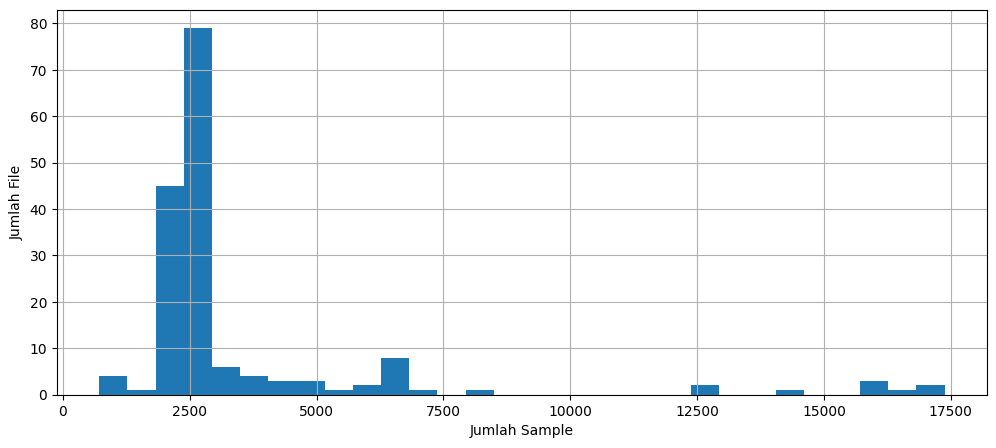

In [33]:
plt.figure(figsize=(12,5))

plt.hist(info_df["samples"], bins=30)

plt.xlabel("Jumlah Sample")
plt.ylabel("Jumlah File")

plt.grid()

plt.show()

In [34]:
info_df.groupby("class")["samples"].mean()

,samples
class,
diam,10301.090909
diamjatuh,2679.191176
jalan,6752.941176
jalanjatuh,2609.140845


In [35]:
info_df.groupby("class")["samples"].count()

,samples
class,
diam,11
diamjatuh,68
jalan,17
jalanjatuh,71


In [36]:
target_file = long_files.iloc[0]["file"]

target_class = long_files.iloc[0]["class"]

target_path = os.path.join(
    path,
    target_class,
    target_file
)

print(target_path)

/content/drive/My Drive/Colab Notebooks/datata/diam/diam1.csv


In [37]:
target_file = long_files.iloc[0]["file"]

target_class = long_files.iloc[0]["class"]

target_path = os.path.join(
    path,
    target_class,
    target_file
)

print(target_path)

/content/drive/My Drive/Colab Notebooks/datata/diam/diam1.csv


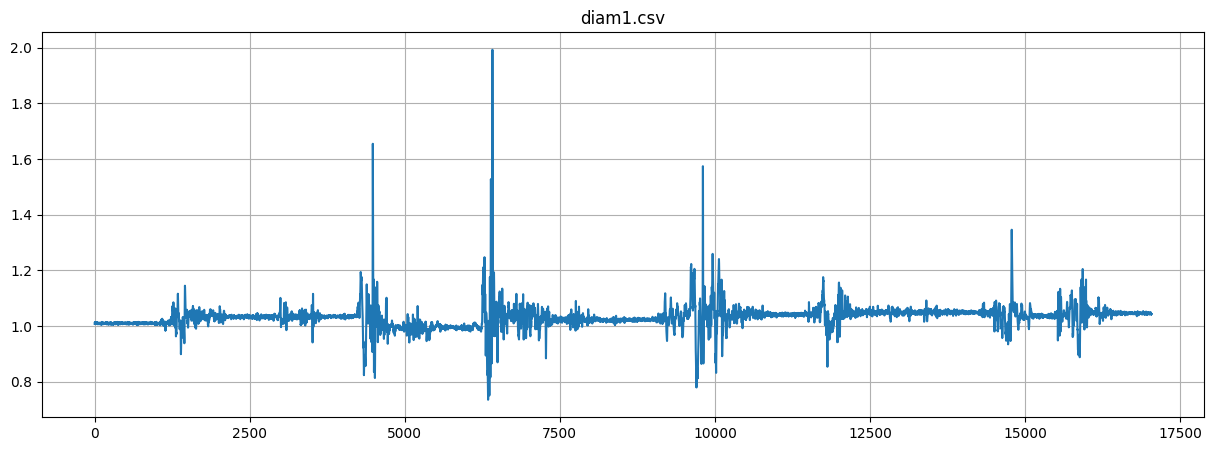

In [38]:
df = pd.read_csv(target_path)

df["acc_mag"] = np.sqrt(
    df["ax"]**2 +
    df["ay"]**2 +
    df["az"]**2
)

plt.figure(figsize=(15,5))

plt.plot(df["acc_mag"])

plt.title(target_file)

plt.grid()

plt.show()

In [39]:
class_count = info_df.groupby("class")["file"].count()

print(class_count)

class
diam          11
diamjatuh     68
jalan         17
jalanjatuh    71
Name: file, dtype: int64


In [40]:
sample_count = info_df.groupby("class")["samples"].sum()

print(sample_count)

class
diam          113312
diamjatuh     182185
jalan         114800
jalanjatuh    185249
Name: samples, dtype: int64


In [41]:
duration_count = info_df.groupby("class")["duration_sec"].sum()

print(duration_count)

class
diam          566.560
diamjatuh     910.925
jalan         574.000
jalanjatuh    926.245
Name: duration_sec, dtype: float64


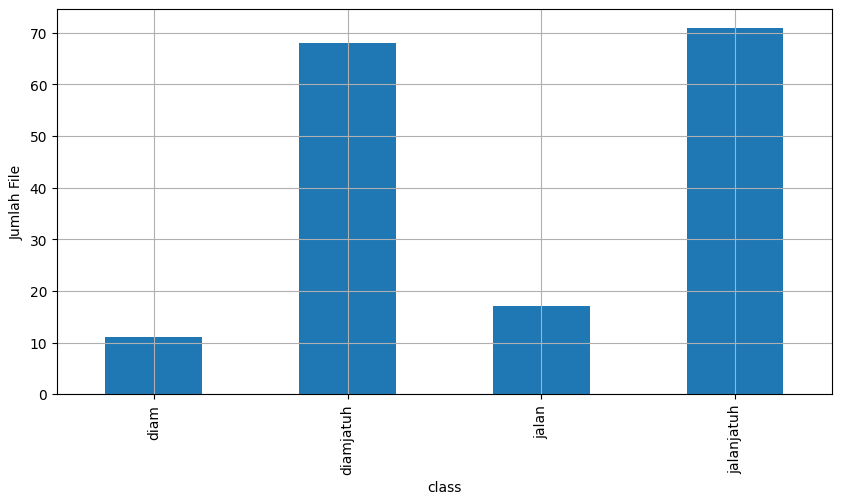

In [42]:
plt.figure(figsize=(10,5))

class_count.plot(kind="bar")

plt.ylabel("Jumlah File")
plt.grid()

plt.show()

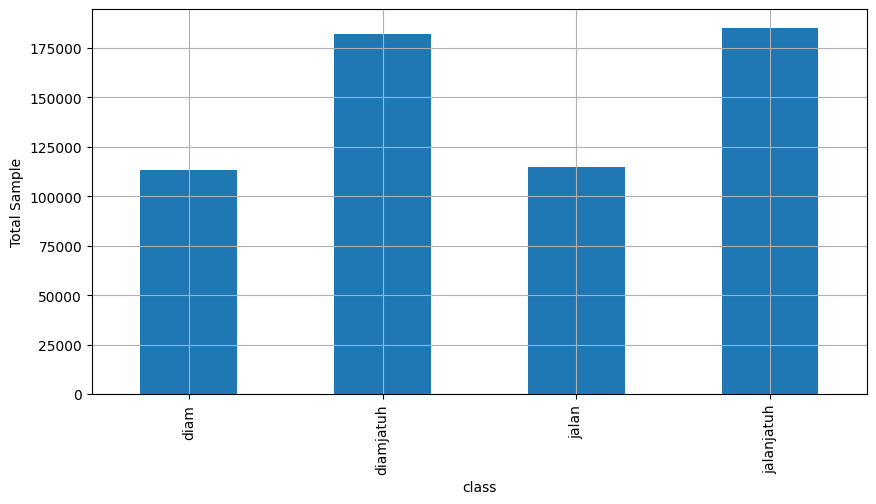

In [43]:
plt.figure(figsize=(10,5))

sample_count.plot(kind="bar")

plt.ylabel("Total Sample")
plt.grid()

plt.show()

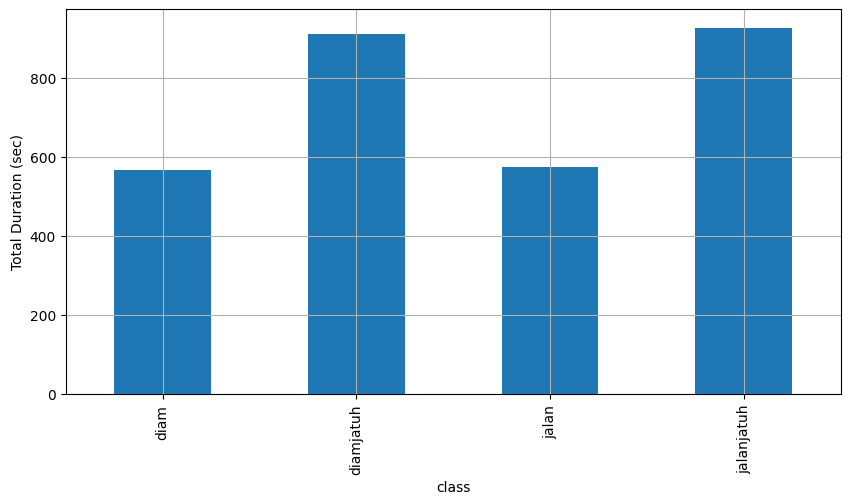

In [44]:
plt.figure(figsize=(10,5))

duration_count.plot(kind="bar")

plt.ylabel("Total Duration (sec)")
plt.grid()

plt.show()

In [45]:
info_df[
    info_df["class"] == "diamjatuh"
].sort_values(
    by="samples"
)

,class,file,samples,duration_sec
90,diamjatuh,diamjatuh_tidurmenjangkau_kanan_langsung1.csv,717,3.585
35,diamjatuh,diamjatuh_05.csv,826,4.130
83,diamjatuh,diamjatuh_dudukmenjangkau_depan_langsung.csv,2099,10.495
82,diamjatuh,diamjatuh_dudukmenjangkau_belakang_langsung.csv,2205,11.025
40,diamjatuh,diamjatuh_berdiri_kanan_tangan (2).csv,2229,11.145
...,...,...,...,...
74,diamjatuh,diamjatuh_dudukmenjangkau_kanan_tangan (4).csv,3968,19.840
38,diamjatuh,diamjatuh_berdiri_depan_langsung (2).csv,4006,20.030
85,diamjatuh,diamjatuh_tidurmenjangkau_kiri_tangan.csv,4141,20.705
76,diamjatuh,diamjatuh_dudukmenjangkau_kanan_tangan (2).csv,5786,28.930


In [46]:
info_df[
    info_df["class"] == "jalanjatuh"
].sort_values(
    by="samples"
)

,class,file,samples,duration_sec
141,jalanjatuh,jalanjatuh_b5cepat_tersandung_tangan.csv,949,4.745
166,jalanjatuh,jalanpelan_terpeleset_tangan.csv,1627,8.135
156,jalanjatuh,jalannormal_tersandung_langsung.csv,1893,9.465
134,jalanjatuh,jalanjatuh_jnormal_tersandung_langsung.csv,1988,9.940
151,jalanjatuh,jalanmundur_sampingkiri_langsung.csv,2147,10.735
...,...,...,...,...
139,jalanjatuh,jalanjatuh_jcepat_tersandung_tangan.csv,4320,21.600
138,jalanjatuh,jalanjatuh_jpelan_tersandung_langsung.csv,4698,23.490
135,jalanjatuh,jalanjatuh_jnormal_tersandung_tangan.csv,4826,24.130
136,jalanjatuh,jalanjatuh_jnormal_tersandung_tangan (2).csv,4982,24.910


In [47]:
info_df[
    info_df["class"] == "diam"
].sort_values(
    by="samples"
)

,class,file,samples,duration_sec
6,diam,membungkuk_20260524_020823.csv,6316,31.580
5,diam,melihat_hp_20260524_020724.csv,6455,32.275
8,diam,gerak_tangan_kecil_20260524_021025.csv,6464,32.320
9,diam,geser_badan_20260524_021124.csv,6636,33.180
4,diam,diam_rebahsantai_20260524_020550.csv,6669,33.345
7,diam,duduk_berubah_posisi_20260524_020925.csv,6888,34.440
10,diam,diam_tangandada_20260526_021303.csv,8072,40.360
3,diam,diam4.csv,16117,80.585
1,diam,diam2.csv,16224,81.120
2,diam,diam3.csv,16431,82.155


In [48]:
info_df[
    info_df["class"] == "jalan"
].sort_values(
    by="samples"
)

,class,file,samples,duration_sec
26,jalan,berdiri_lalu_jalan03_20260524_022409.csv,792,3.960
20,jalan,jalan_lalu_duduk01_20260524_021934.csv,2284,11.420
27,jalan,berdiri_lalu_jalan03_20260524_022414.csv,2380,11.900
21,jalan,jalan_lalu_duduk02_20260524_022001.csv,2416,12.080
22,jalan,jalan_lalu_duduk03_20260524_022032.csv,2423,12.115
25,jalan,berdiri_lalu_jalan03_20260524_022355.csv,2498,12.490
24,jalan,berdiri_lalu_jalan02_20260524_022304.csv,2633,13.165
23,jalan,berdiri_lalu_jalan01_20260524_022206.csv,2655,13.275
19,jalan,jalan_lalu_duduk01_20260524_021911.csv,4199,20.995
17,jalan,jalan_belok_cepat_20260524_021339.csv,6435,32.175


In [49]:
target_class = "diamjatuh"

target_folder = os.path.join(
    path,
    target_class
)

target_files = os.listdir(target_folder)

print("Jumlah file :", len(target_files))

Jumlah file : 68


In [51]:
random_file = np.random.choice(target_files)

target_path = os.path.join(
    target_folder,
    random_file
)

print(target_path)

/content/drive/My Drive/Colab Notebooks/datata/diamjatuh/diamjatuh_berdiri_kiri_langsung.csv


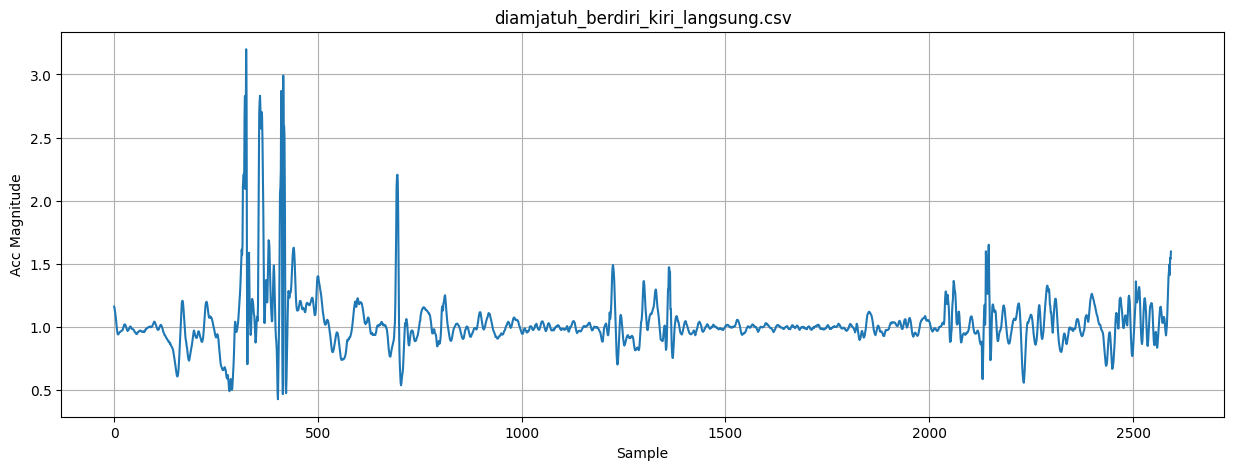

In [52]:
df = pd.read_csv(target_path)

df["acc_mag"] = np.sqrt(
    df["ax"]**2 +
    df["ay"]**2 +
    df["az"]**2
)

plt.figure(figsize=(15,5))

plt.plot(df["acc_mag"])

plt.title(random_file)

plt.xlabel("Sample")

plt.ylabel("Acc Magnitude")

plt.grid()

plt.show()

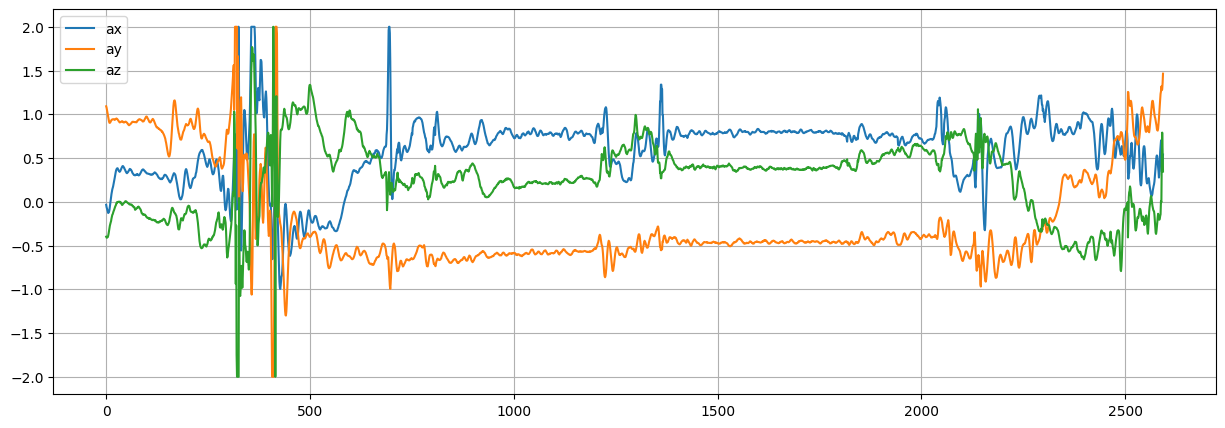

In [53]:
plt.figure(figsize=(15,5))

plt.plot(df["ax"], label="ax")
plt.plot(df["ay"], label="ay")
plt.plot(df["az"], label="az")

plt.legend()

plt.grid()

plt.show()

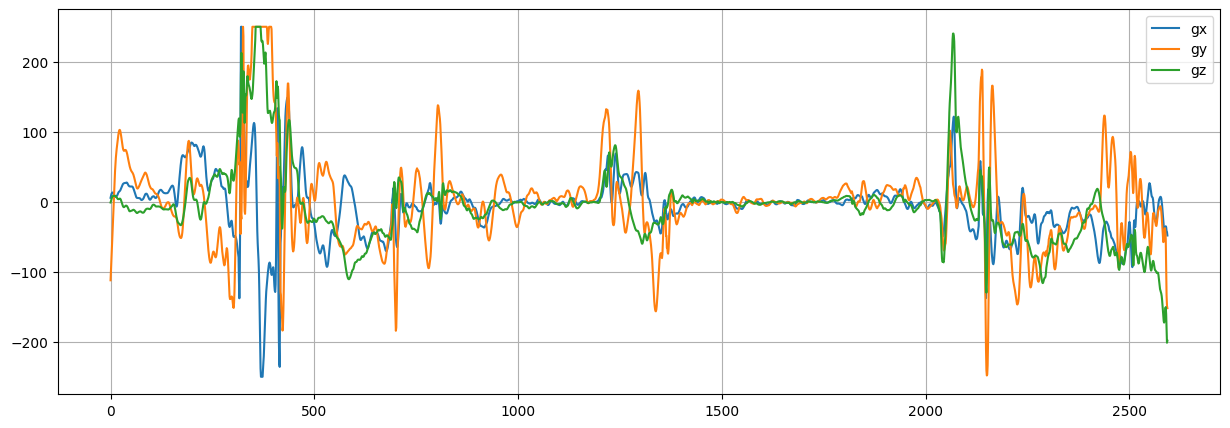

In [54]:
plt.figure(figsize=(15,5))

plt.plot(df["gx"], label="gx")
plt.plot(df["gy"], label="gy")
plt.plot(df["gz"], label="gz")

plt.legend()

plt.grid()

plt.show()

In [55]:
bad_files = []

for cls in classes:

    folder = os.path.join(path, cls)

    if os.path.isdir(folder):

        files = os.listdir(folder)

        for f in files:

            fp = os.path.join(folder, f)

            try:

                df = pd.read_csv(fp)

                if len(df) == 0:

                    bad_files.append([
                        cls,
                        f,
                        "empty"
                    ])

                    continue

                required_columns = [
                    "ax",
                    "ay",
                    "az",
                    "gx",
                    "gy",
                    "gz"
                ]

                for col in required_columns:

                    if col not in df.columns:

                        bad_files.append([
                            cls,
                            f,
                            f"missing_{col}"
                        ])

            except Exception as e:

                bad_files.append([
                    cls,
                    f,
                    str(e)
                ])

In [56]:
bad_df = pd.DataFrame(
    bad_files,
    columns=[
        "class",
        "file",
        "problem"
    ]
)

bad_df

,class,file,problem


In [57]:
print("Jumlah file bermasalah :", len(bad_df))

Jumlah file bermasalah : 0


In [58]:
all_windows = []

WINDOW_SIZE = 400
STEP = 200

for cls in classes:

    folder = os.path.join(path, cls)

    if os.path.isdir(folder):

        files = os.listdir(folder)

        total_window_class = 0

        for f in files:

            fp = os.path.join(folder, f)

            try:

                df = pd.read_csv(fp)

                total_sample = len(df)

                n_window = (
                    (total_sample - WINDOW_SIZE) // STEP
                ) + 1

                if n_window > 0:

                    total_window_class += n_window

            except:
                pass

        all_windows.append([
            cls,
            total_window_class
        ])

In [59]:
window_df = pd.DataFrame(
    all_windows,
    columns=[
        "class",
        "total_window"
    ]
)

window_df

,class,total_window
0,diam,552
1,jalan,548
2,diamjatuh,808
3,jalanjatuh,819


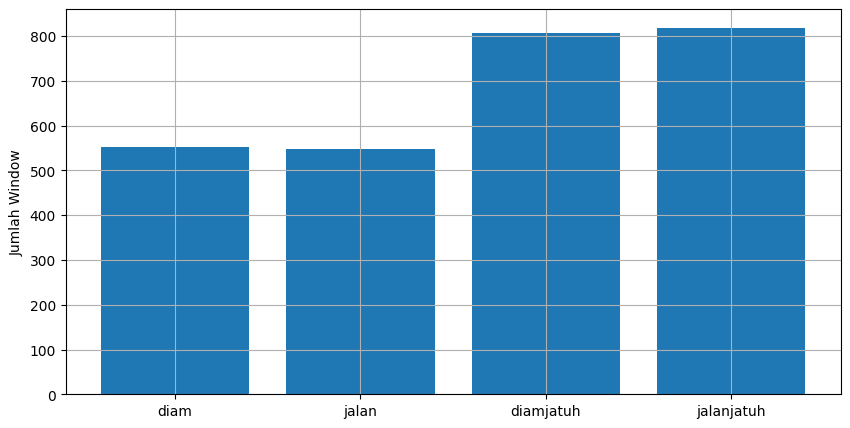

In [60]:
plt.figure(figsize=(10,5))

plt.bar(
    window_df["class"],
    window_df["total_window"]
)

plt.ylabel("Jumlah Window")

plt.grid()

plt.show()

In [61]:
print(
    "TOTAL WINDOW DATASET :",
    window_df["total_window"].sum()
)

TOTAL WINDOW DATASET : 2727


In [62]:
window_df["percentage"] = (
    window_df["total_window"] /
    window_df["total_window"].sum()
) * 100

window_df

,class,total_window,percentage
0,diam,552,20.242024
1,jalan,548,20.095343
2,diamjatuh,808,29.629630
3,jalanjatuh,819,30.033003


In [63]:
window_df.sort_values(
    by="total_window",
    ascending=False
)

,class,total_window,percentage
3,jalanjatuh,819,30.033003
2,diamjatuh,808,29.629630
0,diam,552,20.242024
1,jalan,548,20.095343


In [64]:
target_class = "diamjatuh"

folder = os.path.join(
    path,
    target_class
)

files = os.listdir(folder)

window_per_file = []

for f in files:

    fp = os.path.join(folder, f)

    try:

        df = pd.read_csv(fp)

        total_sample = len(df)

        n_window = (
            (total_sample - WINDOW_SIZE) // STEP
        ) + 1

        window_per_file.append([
            f,
            total_sample,
            n_window
        ])

    except:
        pass

In [65]:
window_file_df = pd.DataFrame(
    window_per_file,
    columns=[
        "file",
        "samples",
        "windows"
    ]
)

window_file_df.sort_values(
    by="windows",
    ascending=False
)

,file,samples,windows
58,diamjatuh_tidurmenjangkau_kiri_tangan (2).csv,5876,28
48,diamjatuh_dudukmenjangkau_kanan_tangan (2).csv,5786,27
57,diamjatuh_tidurmenjangkau_kiri_tangan.csv,4141,19
10,diamjatuh_berdiri_depan_langsung (2).csv,4006,19
46,diamjatuh_dudukmenjangkau_kanan_tangan (4).csv,3968,18
...,...,...,...
56,diamjatuh_dudukmenjangkau_depan_tangan.csv,2355,10
59,diamjatuh_tidurmenjangkau_kiri_tangan (3).csv,2356,10
55,diamjatuh_dudukmenjangkau_depan_langsung.csv,2099,9
7,diamjatuh_05.csv,826,3


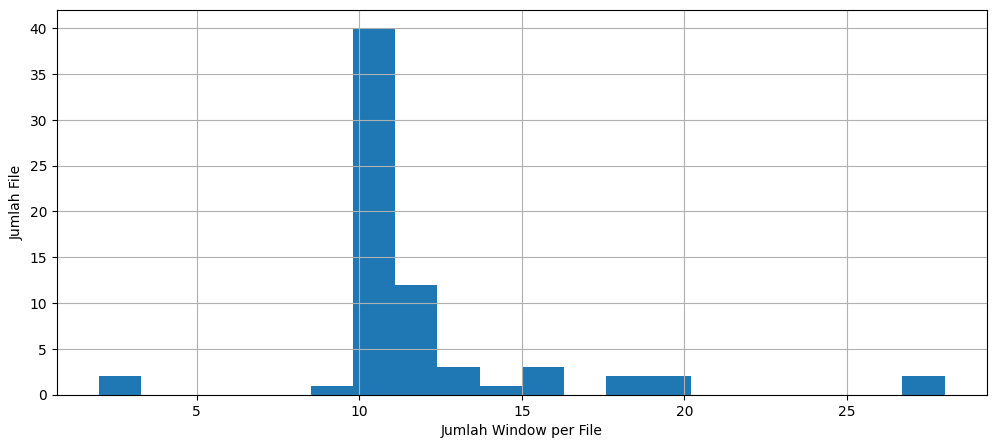

In [66]:
plt.figure(figsize=(12,5))

plt.hist(
    window_file_df["windows"],
    bins=20
)

plt.xlabel("Jumlah Window per File")

plt.ylabel("Jumlah File")

plt.grid()

plt.show()

In [67]:
few_window = window_file_df[
    window_file_df["windows"] <= 1
]

few_window

,file,samples,windows


In [68]:
print(
    "File dengan window <= 1 :",
    len(few_window)
)

File dengan window <= 1 : 0


In [69]:
WINDOW_SIZE = 400
STEP = 200

label_map = {
    "diam": 0,
    "jalan": 1,
    "diamjatuh": 2,
    "jalanjatuh": 3
}

In [70]:
X = []
y = []

In [71]:
for cls in classes:

    folder = os.path.join(path, cls)

    if os.path.isdir(folder):

        files = os.listdir(folder)

        print("\nPROCESS CLASS :", cls)

        for f in files:

            fp = os.path.join(folder, f)

            try:

                df = pd.read_csv(fp)

                needed = [
                    "ax",
                    "ay",
                    "az",
                    "gx",
                    "gy",
                    "gz"
                ]

                if not all(col in df.columns for col in needed):
                    continue

                data = df[needed].values

                total_sample = len(data)

                if total_sample < WINDOW_SIZE:
                    continue

                for start in range(
                    0,
                    total_sample - WINDOW_SIZE + 1,
                    STEP
                ):

                    end = start + WINDOW_SIZE

                    window = data[start:end]

                    X.append(window)

                    y.append(label_map[cls])

            except Exception as e:

                print("ERROR :", fp)
                print(e)


PROCESS CLASS : diam

PROCESS CLASS : jalan

PROCESS CLASS : diamjatuh

PROCESS CLASS : jalanjatuh


In [72]:
X = np.array(X)

y = np.array(y)

In [73]:
print("X shape :", X.shape)
print("y shape :", y.shape)

X shape : (2727, 400, 6)
y shape : (2727,)


In [74]:
print("Contoh shape 1 window :", X[0].shape)

Contoh shape 1 window : (400, 6)


In [75]:
print("Contoh label :", y[:20])

Contoh label : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [76]:
unique, counts = np.unique(
    y,
    return_counts=True
)

for u, c in zip(unique, counts):

    print(
        "Label",
        u,
        ":",
        c,
        "windows"
    )

Label 0 : 552 windows
Label 1 : 548 windows
Label 2 : 808 windows
Label 3 : 819 windows


In [77]:
from sklearn.model_selection import train_test_split

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [79]:
print("TRAIN :", X_train.shape)
print("TEST  :", X_test.shape)

TRAIN : (2181, 400, 6)
TEST  : (546, 400, 6)


In [80]:
mean = X_train.mean(
    axis=(0,1),
    keepdims=True
)

std = X_train.std(
    axis=(0,1),
    keepdims=True
)

In [81]:
X_train = (X_train - mean) / std

X_test = (X_test - mean) / std

In [82]:
print(X_train.shape)
print(X_test.shape)

(2181, 400, 6)
(546, 400, 6)


In [83]:
sample_window = X_train[0]

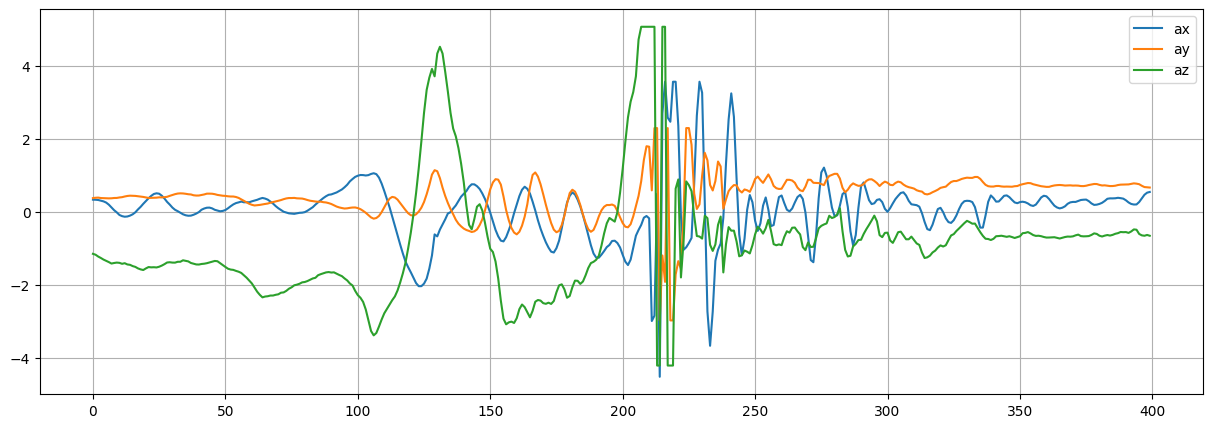

In [84]:
plt.figure(figsize=(15,5))

plt.plot(sample_window[:,0], label="ax")
plt.plot(sample_window[:,1], label="ay")
plt.plot(sample_window[:,2], label="az")

plt.legend()

plt.grid()

plt.show()

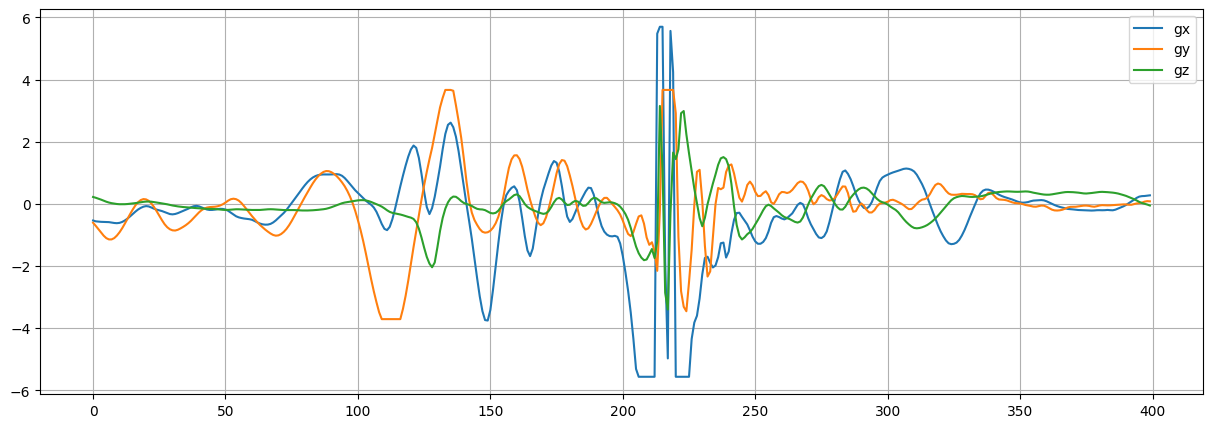

In [85]:
plt.figure(figsize=(15,5))

plt.plot(sample_window[:,3], label="gx")
plt.plot(sample_window[:,4], label="gy")
plt.plot(sample_window[:,5], label="gz")

plt.legend()

plt.grid()

plt.show()

In [87]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [88]:
model = Sequential()

In [89]:
model.add(

    Conv1D(
        filters=32,
        kernel_size=3,
        activation="relu",
        input_shape=(400,6)
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [90]:
model.add(

    Conv1D(
        filters=32,
        kernel_size=3,
        activation="relu",
        input_shape=(400,6)
    )
)

In [91]:
model.add(
    MaxPooling1D(pool_size=2)
)

In [92]:
model.add(
    Dropout(0.3)
)

In [93]:
model.add(

    Conv1D(
        filters=64,
        kernel_size=3,
        activation="relu"
    )
)

In [94]:
model.add(
    MaxPooling1D(pool_size=2)
)

In [95]:
model.add(
    Dropout(0.3)
)

In [96]:
model.add(
    Flatten()
)

In [97]:
model.add(
    Dense(
        128,
        activation="relu"
    )
)

In [98]:
model.add(
    Dropout(0.5)
)

In [99]:
model.add(
    Dense(
        4,
        activation="softmax"
    )
)

In [100]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 398, 32)        │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 396, 32)        │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 198, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 198, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 196, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 98, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 98, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 813,380 (3.10 MB)

 Trainable params: 813,380 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [101]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [102]:
history = model.fit(

    X_train,
    y_train,

    epochs=30,

    batch_size=32,

    validation_data=(
        X_test,
        y_test
    )
)

Epoch 1/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.5039 - loss: 1.1123 - val_accuracy: 0.5989 - val_loss: 0.9416
Epoch 2/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.6337 - loss: 0.8587 - val_accuracy: 0.6703 - val_loss: 0.7924
Epoch 3/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.6657 - loss: 0.7709 - val_accuracy: 0.6850 - val_loss: 0.7631
Epoch 4/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.7098 - loss: 0.7032 - val_accuracy: 0.7106 - val_loss: 0.7138
Epoch 5/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.7322 - loss: 0.6622 - val_accuracy: 0.6832 - val_loss: 0.7462
Epoch 6/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.7396 - loss: 0.6365 - val_accuracy: 0.7289 - val_loss: 0.6491
Epoch 7/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.7616 - loss: 0.5831 - val_accuracy: 0.7015 - val_loss: 0.6778
Epoch 8/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.7854 - loss: 0.5344 - val_accuracy: 0.7234 - v

In [103]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy :", accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7564 - loss: 0.7584
Accuracy : 0.7564102411270142


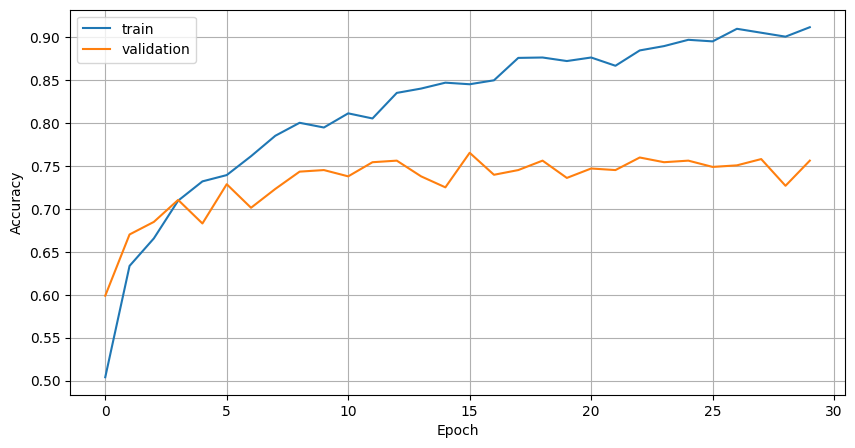

In [104]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["accuracy"],
    label="train"
)

plt.plot(
    history.history["val_accuracy"],
    label="validation"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid()

plt.show()

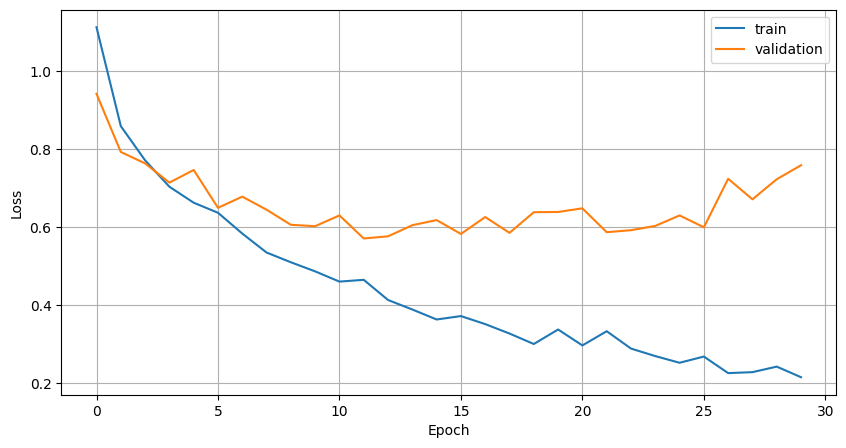

In [105]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="train"
)

plt.plot(
    history.history["val_loss"],
    label="validation"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.show()

In [106]:
y_pred = model.predict(X_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [107]:
y_pred = np.argmax(
    y_pred,
    axis=1
)

In [108]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [109]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[ 84   0  25   1]
 [  3  87   9  11]
 [  1   2 133  26]
 [  1   8  46 109]]


In [110]:
print(

    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.94      0.76      0.84       110
           1       0.90      0.79      0.84       110
           2       0.62      0.82      0.71       162
           3       0.74      0.66      0.70       164

    accuracy                           0.76       546
   macro avg       0.80      0.76      0.77       546
weighted avg       0.78      0.76      0.76       546



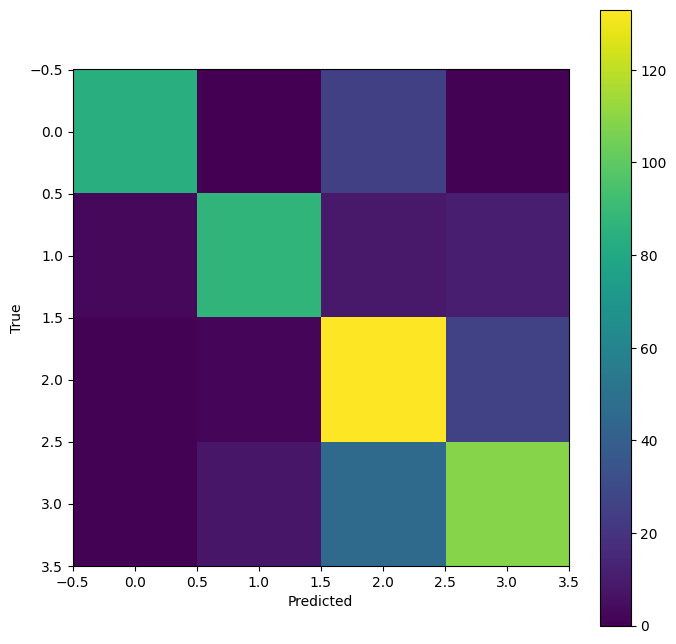

In [111]:
plt.figure(figsize=(8,8))

plt.imshow(cm)

plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [112]:
model.save(
    "fall_detection_cnn1.h5"
)

In [115]:
from google.colab import files

files.download(
    "fall_detection_cnn1.h5"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
(546, 128)
Explained Variance: [0.21875036 0.192606  ]


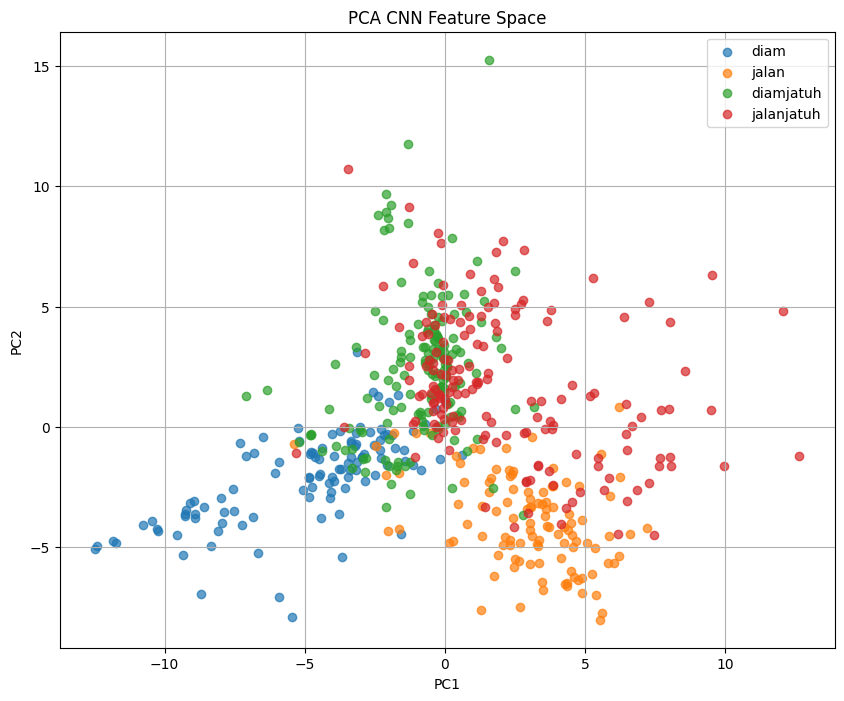

In [126]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Input # Import Input layer

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt


# LOAD MODEL

model = load_model("fall_detection_cnn1.h5")

input_tensor_for_feature_model = Input(shape=X_test.shape[1:])

x = input_tensor_for_feature_model

for layer in model.layers[:-2]:
    x = layer(x)


feature_model = Model(
    inputs=input_tensor_for_feature_model,
    outputs=x
)

# EKSTRAK FITUR

features = feature_model.predict(X_test)

print(features.shape)

# PCA

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

pca = PCA(n_components=2)

pca_result = pca.fit_transform(features_scaled)

print(
    "Explained Variance:",
    pca.explained_variance_ratio_
)

# PLOT

class_names = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

plt.figure(figsize=(10,8))

for i in range(4):

    # y_test is already 1D, so argmax is not needed
    idx = np.where(
        y_test == i
    )

    plt.scatter(
        pca_result[idx,0],
        pca_result[idx,1],
        label=class_names[i],
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "PCA CNN Feature Space"
)

plt.legend()

plt.grid(True)

plt.show()

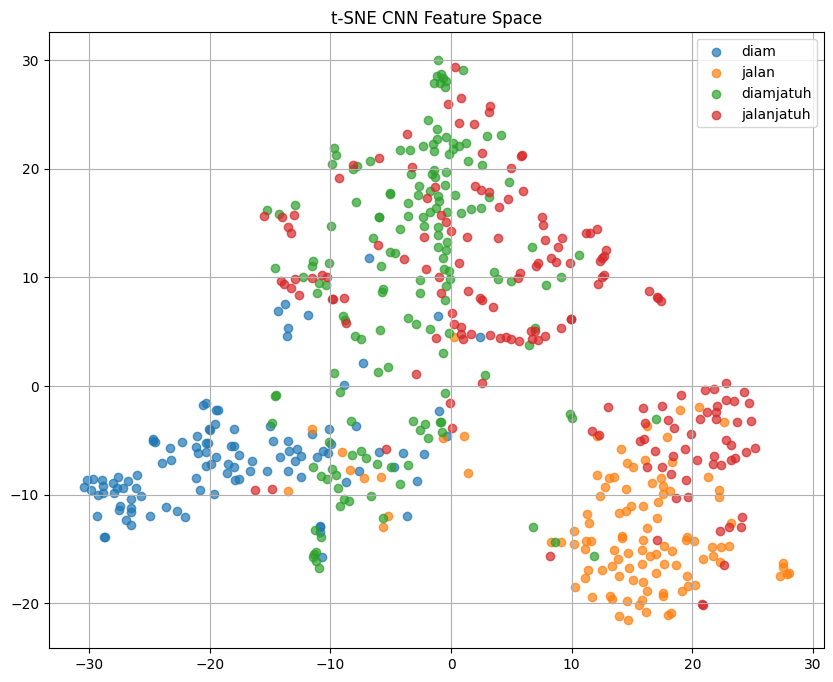

In [129]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

tsne_result = tsne.fit_transform(
    features_scaled
)

plt.figure(figsize=(10,8))

for i in range(4):

    idx = np.where(
        y_test == i
    )

    plt.scatter(
        tsne_result[idx,0],
        tsne_result[idx,1],
        label=class_names[i],
        alpha=0.7
    )

plt.title(
    "t-SNE CNN Feature Space"
)

plt.legend()

plt.grid(True)

plt.show()